In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv(r'C:\Users\HP\Desktop\files\Data\squat_accel_data_friend\30 squat reps, male, 16.csv')

In [3]:
df.head()

,time,ax,ay,az,a_mag
0,0.038367,-7.141379,-6.159724,3.559922,10.080404
1,0.040905,-7.060023,-6.059225,3.626921,9.985624
2,0.043442,-6.973882,-5.982655,3.632305,9.880325
3,0.045980,-6.940382,-5.948557,3.684947,9.855611
4,0.048528,-6.906883,-5.919843,3.689733,9.816501


Text(0.5, 1.0, 'Magnitude of Acceleration with Time.')

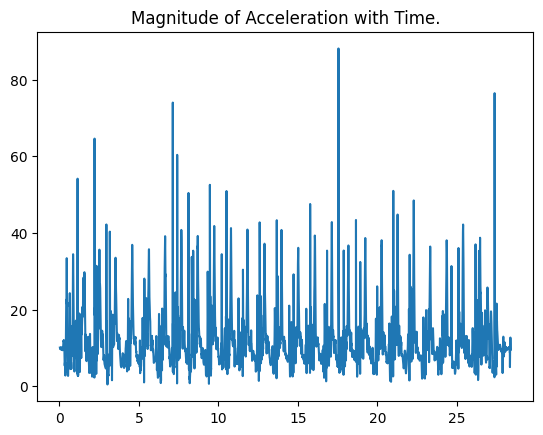

In [4]:
plt.plot(df.time, df.a_mag)
plt.title('Magnitude of Acceleration with Time.') # via acceleromemter on the Oneplus 11R 5G

In [5]:
time = df['time'].values
mask = (time>= 3) & (time <= time[-1] -2) # removes first and last second
df = df[mask].reset_index(drop=True)

Text(0.5, 1.0, 'Magnitude of Acceleration with Time with first three seconds & last two seconds removed')

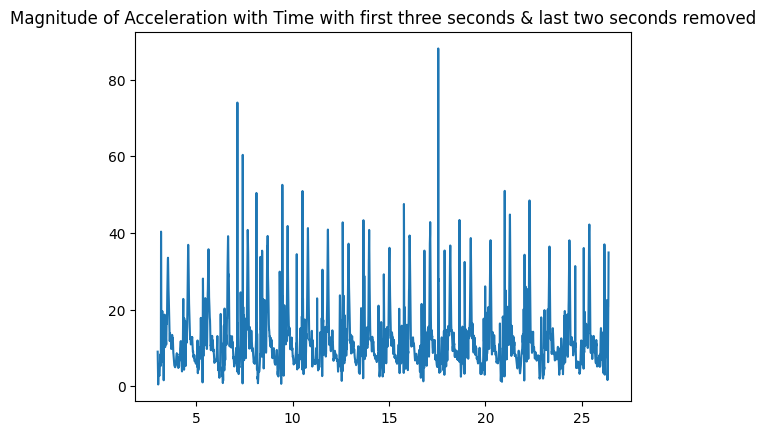

In [6]:
plt.plot(df.time, df.a_mag)
plt.title('Magnitude of Acceleration with Time with first three seconds & last two seconds removed')

In [7]:
window = 25
a_smooth = np.convolve(df.a_mag, np.ones(window)/window, mode = 'same')

Text(0.5, 1.0, 'Magnitude of Smoothened Acceleration with Time.')

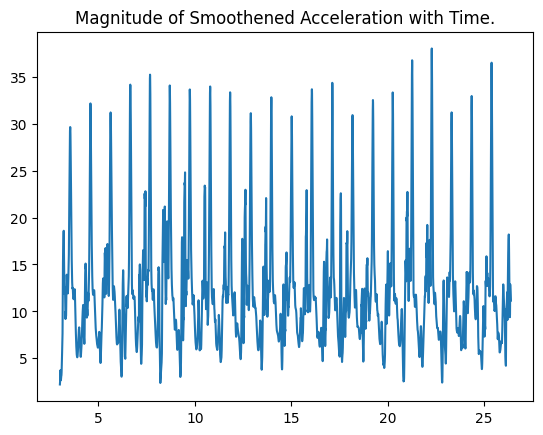

In [8]:
plt.plot(df.time, a_smooth)
plt.title('Magnitude of Smoothened Acceleration with Time.')

In [9]:
from scipy.signal import find_peaks
valleys,_ = find_peaks(-a_smooth, distance = 70, height = -(7.0), prominence = 5.4) # peaks to valleys with -ve
print(valleys)
print(f"number of reps = {len(valleys)}")

[ 354  829 1260 1335 1569 1660 1981 2051 2460 2855 3284 3691 4120 4537
 4884 5366 5762 6197 6623 7017 7402 7806 7880 8194 8618 8982 9107]
number of reps = 27


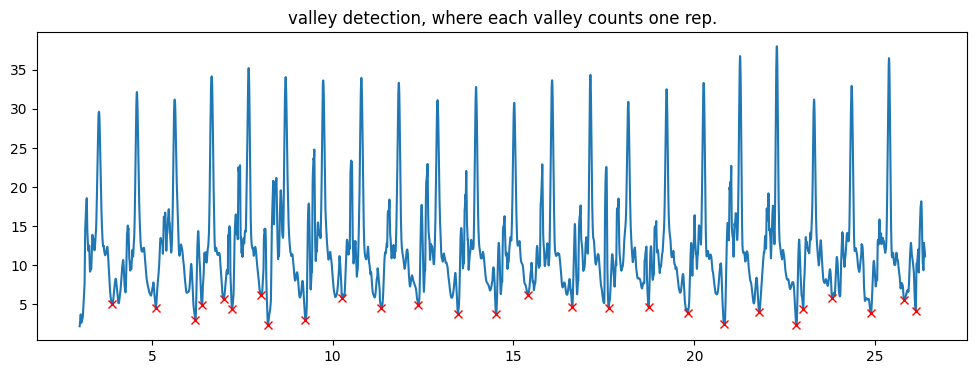

In [10]:
plt.figure(figsize=(12,4))
plt.plot(df.time, a_smooth)
plt.plot(df.time[valleys], a_smooth[valleys], 'rx')
plt.title("valley detection, where each valley counts one rep.")
plt.show()

In [11]:
#next -> finding rep duration then depth
#then ML for rep quality, smoothness, fatigue

In [12]:
print(valleys)
time_stamp = df.time[valleys]
time_intervals = []
for i in range(len(time_stamp)):
  if i == 0:
    time_intervals.append(time_stamp.iloc[i])
  else:
    time_intervals.append(time_stamp.iloc[i] - time_stamp.iloc[i-1])
print(time_intervals)

[ 354  829 1260 1335 1569 1660 1981 2051 2460 2855 3284 3691 4120 4537
 4884 5366 5762 6197 6623 7017 7402 7806 7880 8194 8618 8982 9107]
[np.float64(3.900482398), np.float64(1.2060353650000004), np.float64(1.0945398949999996), np.float64(0.19027499999999975), np.float64(0.5943422920000003), np.float64(0.23107119800000042), np.float64(0.8146225000000005), np.float64(0.17801916699999865), np.float64(1.0387406769999998), np.float64(1.0029984380000005), np.float64(1.0893254700000004), np.float64(1.0327046299999996), np.float64(1.0900901100000002), np.float64(1.0583815100000002), np.float64(0.8815880200000006), np.float64(1.2239003099999994), np.float64(1.0050463), np.float64(1.1050396899999981), np.float64(1.0817030700000032), np.float64(1.0004497999999984), np.float64(0.9771696799999994), np.float64(1.0262708400000022), np.float64(0.18790217999999825), np.float64(0.7973120899999984), np.float64(1.0757418700000017), np.float64(0.9245065600000011), np.float64(0.3180316199999993)]


In [13]:
print(df.time[valleys])

354      3.900482
829      5.106518
1260     6.201058
1335     6.391333
1569     6.985675
1660     7.216746
1981     8.031369
2051     8.209388
2460     9.248128
2855    10.251127
3284    11.340452
3691    12.373157
4120    13.463247
4537    14.521629
4884    15.403217
5366    16.627117
5762    17.632163
6197    18.737203
6623    19.818906
7017    20.819356
7402    21.796526
7806    22.822796
7880    23.010699
8194    23.808011
8618    24.883752
8982    25.808259
9107    26.126291
Name: time, dtype: float64


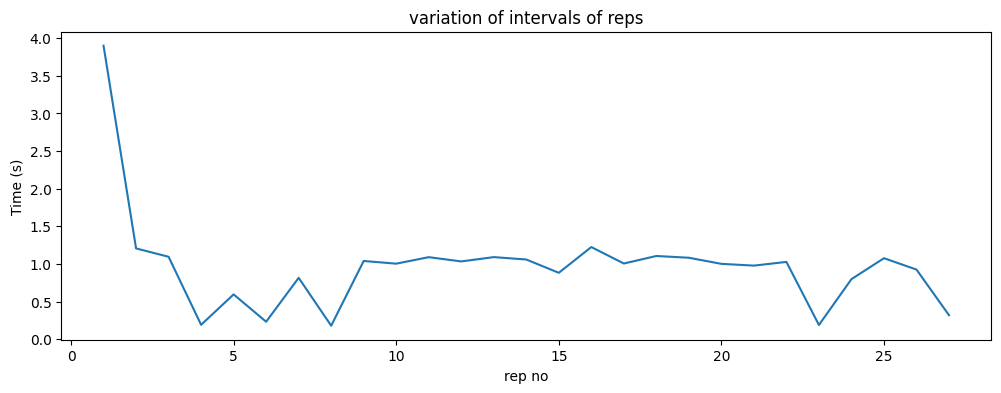

In [14]:
plt.figure(figsize = (12,4))
plt.plot(range(1,len(time_intervals)+1), time_intervals)
plt.title('variation of intervals of reps')
plt.ylabel('Time (s)')
plt.xlabel('rep no')
plt.show()


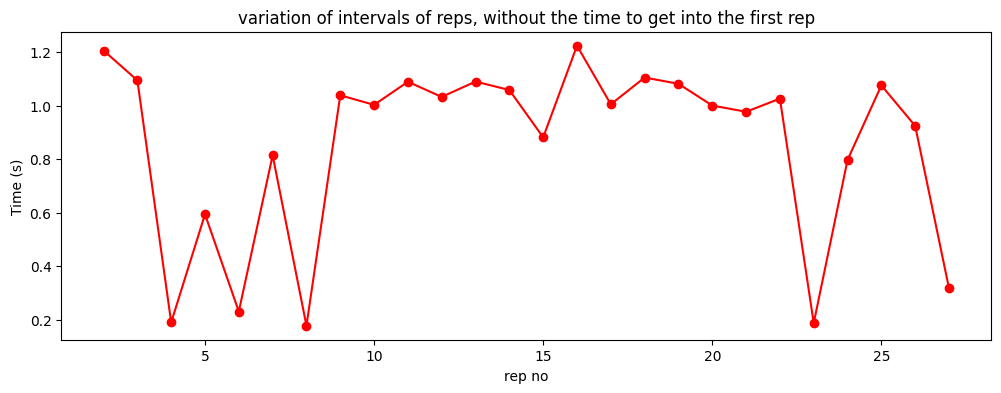

In [15]:
plt.figure(figsize = (12,4))
plt.plot(range(2,(len(time_intervals)+1)), time_intervals[1:], marker = 'o', color = 'r')
plt.title('variation of intervals of reps, without the time to get into the first rep')
plt.ylabel('Time (s)')
plt.xlabel('rep no')
plt.show()

In [16]:
time_intervals_list = list(map(lambda x: float(x), time_intervals)) #converting values to python list type
print(time_intervals_list)

[3.900482398, 1.2060353650000004, 1.0945398949999996, 0.19027499999999975, 0.5943422920000003, 0.23107119800000042, 0.8146225000000005, 0.17801916699999865, 1.0387406769999998, 1.0029984380000005, 1.0893254700000004, 1.0327046299999996, 1.0900901100000002, 1.0583815100000002, 0.8815880200000006, 1.2239003099999994, 1.0050463, 1.1050396899999981, 1.0817030700000032, 1.0004497999999984, 0.9771696799999994, 1.0262708400000022, 0.18790217999999825, 0.7973120899999984, 1.0757418700000017, 0.9245065600000011, 0.3180316199999993]


In [17]:
# depth calculation of each rep

[ 354  829 1260 1335 1569 1660 1981 2051 2460 2855 3284 3691 4120 4537
 4884 5366 5762 6197 6623 7017 7402 7806 7880 8194 8618 8982 9107]

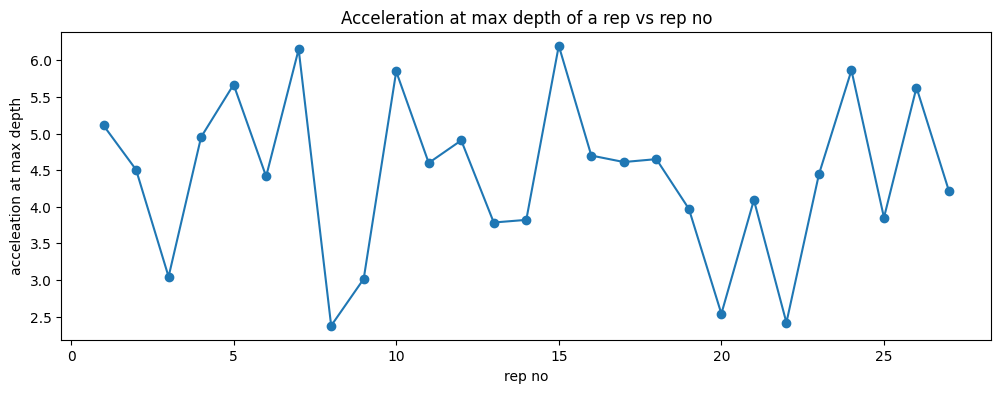

In [18]:
#graph of acceleation vs rep no
print(valleys)
rep_depth = a_smooth[valleys]
plt.figure(figsize = (12,4))
plt.plot(range(1,len(rep_depth)+1), rep_depth, marker = 'o')
plt.title("Acceleration at max depth of a rep vs rep no")
plt.xlabel('rep no')
plt.ylabel("acceleation at max depth")
plt.show()

In [19]:
df.head()

,time,ax,ay,az,a_mag
0,3.001634,-0.983450,-2.228316,8.678768,9.014077
1,3.004173,-1.390230,-1.821536,7.951350,8.274944
2,3.006712,-1.557728,-1.452443,7.180263,7.489478
3,3.009251,-1.625325,-1.131805,6.423532,6.721937
4,3.011791,-1.375873,-0.902094,5.604589,5.841080


In [20]:
print(time_intervals_list)
print(rep_depth)
rep_no = list(range(1, len(rep_depth) +1))
print(rep_no)
rep_time = time_stamp # for easier intuition
print(len(time_intervals_list))

[3.900482398, 1.2060353650000004, 1.0945398949999996, 0.19027499999999975, 0.5943422920000003, 0.23107119800000042, 0.8146225000000005, 0.17801916699999865, 1.0387406769999998, 1.0029984380000005, 1.0893254700000004, 1.0327046299999996, 1.0900901100000002, 1.0583815100000002, 0.8815880200000006, 1.2239003099999994, 1.0050463, 1.1050396899999981, 1.0817030700000032, 1.0004497999999984, 0.9771696799999994, 1.0262708400000022, 0.18790217999999825, 0.7973120899999984, 1.0757418700000017, 0.9245065600000011, 0.3180316199999993]
[5.11011452 4.50576759 3.04411022 4.95169306 5.66883305 4.41389428
 6.15043341 2.37457019 3.01398965 5.8484168  4.59840188 4.90645006
 3.78463168 3.82050651 6.19950686 4.69917375 4.61065904 4.65026009
 3.97160031 2.53793735 4.09197046 2.41725617 4.44315017 5.86379363
 3.85193222 5.62874407 4.21211278]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


In [21]:
#finding peaks of a_smooth
peaks,_ = find_peaks(a_smooth, distance = 100, height = (7.0), prominence = 5.4)
print(peaks)
print(f"number of peaks = {len(peaks)}")
print(len(peaks), len(valleys))

[  78  210  524  624 1035 1292 1438 1841 2015 2142 2244 2652 2958 3069
 3374 3476 3790 3899 4211 4318 4628 4733 5039 5146 5456 5563 5736 5869
 5975 6280 6393 6697 6797 7193 7594 7836 7999 8409 8815 9053 9166]
number of peaks = 41
41 27


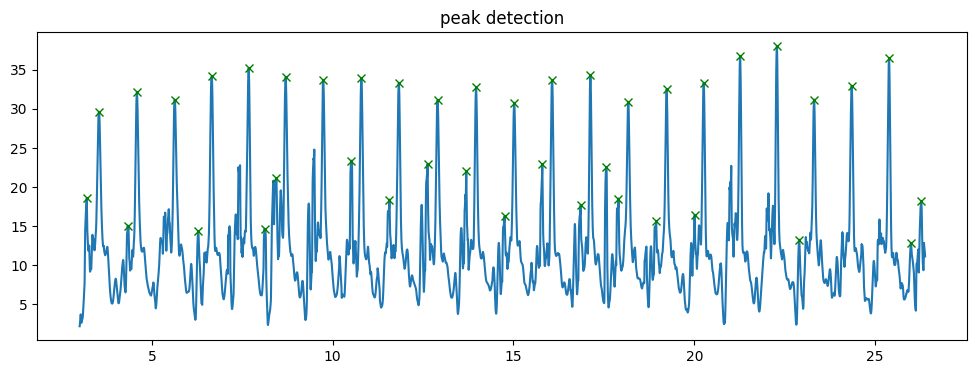

In [22]:
plt.figure(figsize=(12,4))
plt.plot(df.time, a_smooth)
plt.plot(df.time[peaks], a_smooth[peaks], 'gx')
plt.title("peak detection")
plt.show()

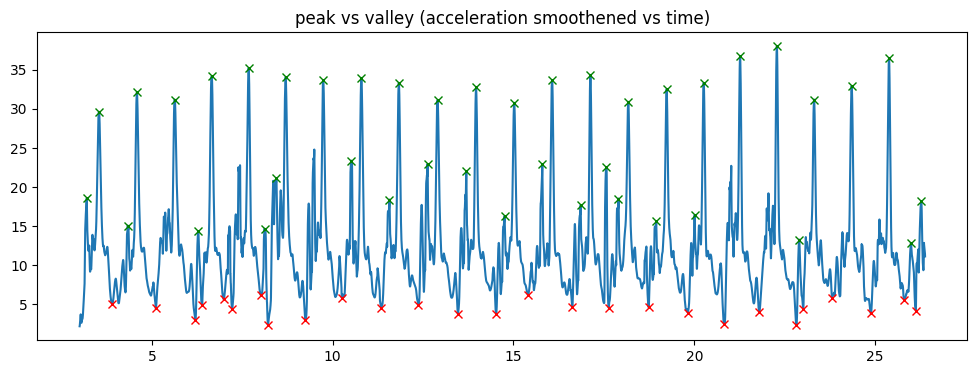

In [23]:
plt.figure(figsize=(12,4))
plt.plot(df.time, a_smooth)
plt.plot(df.time[valleys], a_smooth[valleys], 'rx')
plt.plot(df.time[peaks], a_smooth[peaks], 'gx')
plt.title("peak vs valley (acceleration smoothened vs time)")
plt.show()

In [24]:
valley_a = a_smooth[valleys]
peak_a = a_smooth[peaks]

range_a = []

for i in range(len(valley_a) -1): # last valley corresponds to no peak
    range_a.append(peak_a[i+1] - valley_a[i]) # peak - valley before | valleys are when the user is decelerating towards the ground and peaks are when user is shooting up

range_a = list(map(float, range_a))
print(range_a)

[24.529920388840004, 10.58921109256, 29.112653033439997, 26.245242156584, 8.71575524664, 29.745695616280006, 29.072542682519995, 12.317010535468004, 18.15984339852, 28.221090642279997, 29.04684110864, 18.493055727959995, 30.178130348480007, 14.594875662359998, 27.139494249480006, 18.262083205840003, 26.508734912719998, 17.42243147764, 28.84196216004, 13.745099113560002, 26.692419299039997, 20.5006948072, 29.221363029719996, 11.8037184944, 30.50095852608, 16.953239953279997]


In [25]:
set_df = pd.DataFrame({
    # metadata
    "set_id": 1,
    "set_size": len(rep_no),
    "exercise": "squat",
    "age": 16,
    "date": pd.to_datetime('20/2/2026', dayfirst = True),
    # rep features
    "rep_in_set": rep_no[1:-1],                  # 2 to 7
    "rep_time": rep_time[1:-1],                  # times of reps 2 to 8
    "rep_interval": time_intervals_list[1:-1],   # true intervals only (2-7)
    "rep_depth": rep_depth[1:-1],                # depths of reps 2 to 7
    "range_a":range_a[1:]                        # peak - valley before difference gives 2 to 7
}).reset_index(drop = True)

# removed last rep to ensure range  corresponds to others

set_df.head(6)

# rows = reps, columns = rep features

,set_id,set_size,exercise,age,date,rep_in_set,rep_time,rep_interval,rep_depth,range_a
0,1,27,squat,16,2026-02-20,2,5.106518,1.206035,4.505768,10.589211
1,1,27,squat,16,2026-02-20,3,6.201058,1.094540,3.044110,29.112653
2,1,27,squat,16,2026-02-20,4,6.391333,0.190275,4.951693,26.245242
3,1,27,squat,16,2026-02-20,5,6.985675,0.594342,5.668833,8.715755
4,1,27,squat,16,2026-02-20,6,7.216746,0.231071,4.413894,29.745696
5,1,27,squat,16,2026-02-20,7,8.031369,0.814623,6.150433,29.072543


In [26]:
#fatigue score